# 01｜行為金融學：散戶為什麼一直虧錢？

**核心論文：**
- Kahneman & Tversky (1979), *Prospect Theory*, Econometrica
- Odean (1998), *Are Investors Reluctant to Realize Their Losses?*, Journal of Finance
- Barber & Oden (2000), *Trading is Hazardous to Your Wealth*, Journal of Finance
- Baker & Wurgler (2006), *Investor Sentiment and the Cross-Section of Stock Returns*, Journal of Finance

在學術研究的每一個「市場異象」背後，都有一個共同的元兇：**人類的非理性行為**。
本章不談「應該怎麼做」，而是先正視「人類天生就會犯哪些錯」。

## 說一個你一定聽過的場景

你的長輩（或長輩的朋友）聽說某支股票要漲，打電話叫你趕快買。你懶得研究，想說她以前挺準的，就跟著買了。

結果跌了 30%。

你沒有賣。你告訴自己：「等它漲回來再說。」半年後又跌了 20%，你還是沒動。你心裡說：「賣了才是真的賠。」

後來另一支股票漲了 15%，你趕快賣掉，「落袋為安」。

聽起來很熟悉嗎？

**這不是你的個人失誤，這是人類大腦的預設設定。**

1979 年，Kahneman 和 Tversky 把這些「不理性行為」系統性整理出來，
後來 Odean（1998）分析了 1 萬個真實券商帳戶，Barber & Odean（2000）再擴大到 6 萬個——
他們逐一用數據驗證了這些偏誤，確認散戶的虧損背後有清晰的行為模式。

這一章，我們要用真實論文的數字回答：**散戶到底輸在哪裡，又能怎麼改？**

## 🎯 學習目標
1. 理解展望理論如何描述人類對「獲利」與「虧損」的不對稱感受
2. 認識五個最常見的散戶認知偏誤及其學術依據
3. 用數據看懂「阿媽理論」——情緒頂點往往是市場頂點

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.family'] = [
    'Microsoft YaHei', 'SimHei', 'Heiti TC',
    'PingFang HK', 'STHeiti', 'Arial Unicode MS', 'sans-serif'
]
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings, pathlib
warnings.filterwarnings('ignore')

DATA_DIR = pathlib.Path('data')
DATA_DIR.mkdir(exist_ok=True)
print('環境就緒')

環境就緒


## 1｜展望理論：損失比獲利更痛

想像兩個情境：

- 情境 A：今天賺了 10,000 元
- 情境 B：今天虧了 10,000 元

**理論上，這兩件事的「重量」應該相同——只是方向不同。**

但你的內心呢？大多數人都知道，情境 B 帶來的不舒服，遠遠強過情境 A 帶來的開心。
這不是你個人脆弱，這是人類大腦的演化結果——**損失比獲利更能抓住注意力**，因為在遠古環境裡，失去資源比獲得資源更危險。

**Kahneman & Tversky（1979）的發現：**

> **損失的痛苦 ≈ 獲利喜悅的 2.25 倍**

這叫做**損失厭惡（Loss Aversion）**，它解釋了投資人最常見的行為矛盾：

- 賺了 10%，馬上出場「落袋為安」——其實是因為害怕「快樂消失」
- 虧了 30%，死抱不賣「等它回來」——其實是因為「確認虧損」太痛
- 明明停損是理性選擇，但就是做不到——這不是意志力問題，是大腦的預設

用數學語言說：人類感知的「價值」不是線性的，而是一條不對稱的 S 型曲線。

In [ ]:
# 展望理論的價值函數 vs 傳統效用函數
x = np.linspace(-200, 200, 1000)

def prospect_value(x, alpha=0.88, beta=0.88, lambda_=2.25):
    """Tversky & Kahneman (1992) 的價值函數參數"""
    v = np.where(x >= 0,
                  x ** alpha,
                 -lambda_ * ((-x) ** beta))
    return v

def linear_utility(x):
    return x

pv = prospect_value(x)
lu = linear_utility(x)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左圖：完整價值函數
ax = axes[0]
ax.plot(x, pv, color='#E91E63', linewidth=2.5, label='展望理論價值函數')
ax.plot(x, lu * 0.8, color='#9E9E9E', linewidth=1.5, linestyle='--', label='傳統效用（理性人）')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

# 標注不對稱
gain_100 = prospect_value(np.array([100.0]))[0]
loss_100 = prospect_value(np.array([-100.0]))[0]
ax.annotate(f'+100的喜悅\n={gain_100:.1f}', xy=(100, gain_100),
            xytext=(30, gain_100+30), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='green'), color='green')
ax.annotate(f'-100的痛苦\n={loss_100:.1f}', xy=(-100, loss_100),
            xytext=(-170, loss_100+30), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red'), color='red')
ax.set_xlabel('損益金額', fontsize=11)
ax.set_ylabel('心理感受強度', fontsize=11)
ax.set_title('展望理論：損失的痛苦遠大於獲利的喜悅', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 右圖：確定獲利 vs 賭博的選擇
ax2 = axes[1]
scenarios = {
    '確定獲利\n$5,000': 5000**0.88,
    '50%機率獲利\n$11,000': 0.5 * (11000**0.88),
    '確定虧損\n-$5,000': -2.25*(5000**0.88),
    '50%機率虧損\n-$11,000': 0.5 * (-2.25*(11000**0.88)),
}
colors_bar = ['#4CAF50','#8BC34A','#F44336','#FF7043']
bars = ax2.bar(list(scenarios.keys()), list(scenarios.values()),
               color=colors_bar, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('理性人選賭博，但多數人選確定獲利\n（損失時反而選賭博，因為損失痛苦太大）',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('展望理論主觀價值')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data/prospect_theory.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'損失厭惡係數 λ = 2.25')
print(f'+100 的喜悅：{gain_100:.1f}')
print(f'-100 的痛苦：{loss_100:.1f}')
print(f'痛苦/喜悅 比值：{abs(loss_100/gain_100):.2f}x')

## 2｜處置效應：賣贏留輸（散戶最常見的錯誤）

**Odean（1998）** 分析了10,000個散戶券商帳戶：

> 散戶賣出「賺錢股票」的機率，是賣出「虧錢股票」的 **1.5 倍**。

這叫 **處置效應（Disposition Effect）**：
- 🟢 賺錢 → 馬上賣，鎖住獲利（因為展望理論：確定獲利 > 繼續賭）
- 🔴 虧錢 → 死抱不賣，等「回本」（因為展望理論：確定虧損太痛，寧願賭一把）

**諷刺的是：** 動能研究告訴我們，強勢股往往繼續漲，弱勢股往往繼續跌。
散戶的處置效應剛好反著做。

In [ ]:
# ── 來源：Odean (1998) Table 1 & Table 3，真實券商帳戶數據 ──
# 資料期間：1987–1993，10,000 個散戶帳戶，162,948 筆交易

# 論文 Table 3 原始月度數據
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
pgr = [0.167, 0.143, 0.155, 0.152, 0.153, 0.148,
       0.150, 0.144, 0.152, 0.155, 0.138, 0.127]  # 獲利實現率
plr = [0.099, 0.094, 0.098, 0.097, 0.097, 0.094,
       0.094, 0.092, 0.095, 0.096, 0.098, 0.154]  # 虧損實現率（12月稅損賣出暴增）

pgr_mean = 0.1484  # 全年平均 PGR（Table 1）
plr_mean = 0.0980  # 全年平均 PLR（Table 1）

# Table 5 Panel B：賣出後 252 天的後續報酬
ret_sold_winners  =  0.0243   # 散戶賣掉的獲利股，一年後漲了 2.4%
ret_kept_losers   = -0.1080   # 散戶留著的虧損股，一年後跌了 10.8%

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左圖：逐月 PGR vs PLR
ax = axes[0]
x_pos = np.arange(len(months))
w = 0.35
ax.bar(x_pos - w/2, [v*100 for v in pgr], w,
       label='PGR（賣出獲利股的比率）', color='#4CAF50', alpha=0.85, edgecolor='white')
ax.bar(x_pos + w/2, [v*100 for v in plr], w,
       label='PLR（賣出虧損股的比率）', color='#F44336', alpha=0.85, edgecolor='white')
ax.axhline(pgr_mean*100, color='#2E7D32', linewidth=1.5, linestyle='--',
           label=f'全年均值 PGR={pgr_mean*100:.1f}%')
ax.axhline(plr_mean*100, color='#B71C1C', linewidth=1.5, linestyle='--',
           label=f'全年均值 PLR={plr_mean*100:.1f}%')
ax.set_xticks(x_pos); ax.set_xticklabels(months)
ax.set_ylabel('實現比率 (%)')
ax.set_title('散戶每個月：賣贏遠多於賣輸\n（12月例外：年底稅損賣出）',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.annotate('12月稅損賣出\nPLR 暴增至 15.4%', xy=(11, plr[11]*100),
            xytext=(8.5, plr[11]*100 + 2.5), fontsize=9, color='#B71C1C',
            arrowprops=dict(arrowstyle='->', color='#B71C1C'))

# 右圖：賣出後 252 天的後續報酬
ax2 = axes[1]
categories = ['散戶賣掉的\n獲利股', '散戶留著的\n虧損股']
values_252 = [ret_sold_winners * 100, ret_kept_losers * 100]
colors_r = ['#4CAF50', '#F44336']
bars = ax2.bar(categories, values_252, color=colors_r,
               alpha=0.85, edgecolor='white', width=0.45)
ax2.axhline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, values_252):
    ax2.text(bar.get_x() + bar.get_width()/2,
             v + (0.4 if v >= 0 else -1.5),
             f'{v:+.1f}%', ha='center', fontsize=14, fontweight='bold')
ax2.set_ylabel('賣出/持有後 252 天的平均報酬 (%)')
ax2.set_title('Odean (1998)：賣掉的股票反而漲更多\n留著的股票繼續跌',
              fontsize=12, fontweight='bold')
ax2.set_ylim(-14, 7)
ax2.grid(alpha=0.3, axis='y')
gap = ret_sold_winners - ret_kept_losers
ax2.text(0.5, 0.08, f'一年後差距 = {gap*100:.1f} 個百分點',
         transform=ax2.transAxes, ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.9))

plt.tight_layout()
plt.savefig('data/disposition_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print('── Odean (1998) 真實券商帳戶數據 ──')
print(f'PGR（賣出獲利股比率）: {pgr_mean*100:.2f}%')
print(f'PLR（賣出虧損股比率）: {plr_mean*100:.2f}%')
print(f'PGR / PLR = {pgr_mean/plr_mean:.2f}x  → 散戶賣贏的機率是賣輸的 1.5 倍')
print(f'\n賣出後 252 天後續報酬（Table 5）：')
print(f'  已賣出的獲利股繼續漲: +{ret_sold_winners*100:.1f}%')
print(f'  繼續持有的虧損股繼續跌: {ret_kept_losers*100:.1f}%')
print(f'  差距: {gap*100:.1f} 個百分點')

## 3｜過度自信：每個人都覺得自己比平均好

問問身邊的人：「你覺得你的開車技術，在台灣所有駕駛裡排在幾%？」

研究發現，80% 以上的人認為自己的開車技術高於平均——但這當然不可能，因為定義上只有 50% 的人高於平均。

**投資市場也一樣。** 大多數主動投資人認為自己能「打敗市場」。但所有投資人的總和，就是市場本身——扣掉交易成本後，平均結果必然低於市場。

問題是：**你越相信自己能選股，你就交易越頻繁——而交易成本是真實的、確定的虧損。**

**Barber & Odean（2000）** 分析 66,465 個散戶帳戶（1991–1997）：

| 族群 | 年換手率 | 年化毛報酬 | 扣費後年化報酬 | **vs 市場** |
|------|----------|------------|----------------|-------------|
| 最低換手（Q1） | 19% | 18.7% | 18.5% | **+1.4%** |
| 最高換手（Q5） | 258% | 15.3% | 11.4% | **−5.7%** |
| 男性平均 | 77% | 19.0% | 16.4% | −0.65% |
| 女性平均 | 53% | 18.7% | 17.0% | −0.13% |

**兩個反直覺的發現：**
1. 換手率越高，報酬越差——不是因為選股能力差，而是**成本**把報酬吃光了
2. 男性換手率高出女性 45%，淨報酬反而低——**過度自信讓男性虧更多**

研究的核心算式就這麼簡單：
$$\text{淨報酬} = \text{選股技術（不穩定）} - \text{交易成本（穩定地被扣走）}$$

In [ ]:
# ── 來源：Barber & Odean (2000) Table IV & Table V，真實數據 ──
# 資料期間：1991–1997，66,465 個散戶帳戶
# 依年換手率分成五組（Q1最低 → Q5最高）

# Table IV 原始數據
quintiles  = ['Q1\n(最低換手)', 'Q2', 'Q3', 'Q4', 'Q5\n(最高換手)']
turnovers  = [19, 56, 113, 188, 258]      # 年換手率 (%)
gross_ret  = [18.7, 17.2, 16.4, 16.0, 15.3]  # 毛報酬 (%)
net_ret    = [18.5, 16.4, 15.5, 14.0, 11.4]  # 淨報酬（扣手續費後）(%)
market_ret = 17.1                              # 同期市場報酬 (%)

# Table V 男女數據（Boys Will Be Boys, 2001）
gender_data = {
    '男性': {'turnover': 77, 'gross': 19.0, 'net': 16.4, 'underperform': 0.65},
    '女性': {'turnover': 53, 'gross': 18.7, 'net': 17.0, 'underperform': 0.13},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左圖：換手率 vs 毛報酬 vs 淨報酬
ax = axes[0]
x = np.arange(len(quintiles))
w = 0.3
b1 = ax.bar(x - w/2, gross_ret, w, label='毛報酬（未扣手續費）',
            color='#90CAF9', alpha=0.9, edgecolor='white')
b2 = ax.bar(x + w/2, net_ret,   w, label='淨報酬（扣手續費後）',
            color='#1565C0', alpha=0.9, edgecolor='white')
ax.axhline(market_ret, color='#F44336', linewidth=2, linestyle='--',
           label=f'市場報酬 {market_ret}%')

for bar, g, n in zip(b1, gross_ret, net_ret):
    cost = g - n
    mid = bar.get_x() + bar.get_width()
    ax.annotate(f'成本\n{cost:.1f}%', xy=(mid + 0.02, n + (g-n)/2),
                fontsize=7.5, color='#B71C1C', ha='left', va='center')

ax.set_xticks(x); ax.set_xticklabels(quintiles)
ax.set_ylabel('年化報酬率 (%)')
ax.set_title('Barber & Odean (2000)：\n換手率越高，淨報酬越低', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(9, 21)
ax.grid(alpha=0.3, axis='y')

# 右圖：男性 vs 女性（Boys Will Be Boys 2001）
ax2 = axes[1]
genders = list(gender_data.keys())
g_turns = [gender_data[g]['turnover'] for g in genders]
g_gross = [gender_data[g]['gross'] for g in genders]
g_net   = [gender_data[g]['net'] for g in genders]

x2 = np.arange(len(genders))
b3 = ax2.bar(x2 - w/2, g_gross, w, label='毛報酬', color='#A5D6A7', alpha=0.9, edgecolor='white')
b4 = ax2.bar(x2 + w/2, g_net,   w, label='淨報酬', color='#2E7D32', alpha=0.9, edgecolor='white')
ax2.axhline(market_ret, color='#F44336', linewidth=2, linestyle='--',
            label=f'市場報酬 {market_ret}%')

for i, g in enumerate(genders):
    ax2.text(i - w/2, g_gross[i] + 0.1, f'{g_gross[i]:.1f}%', ha='center', fontsize=10)
    ax2.text(i + w/2, g_net[i] + 0.1,   f'{g_net[i]:.1f}%',   ha='center', fontsize=10)
    ax2.text(i, 14.5,
             f'換手率\n{g_turns[i]}%/年', ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.8))

ax2.set_xticks(x2); ax2.set_xticklabels(genders, fontsize=13)
ax2.set_ylabel('年化報酬率 (%)')
ax2.set_title('男性交易更頻繁\n淨報酬反而落後女性', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_ylim(13, 21)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data/overconfidence_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print('── Barber & Odean (2000) 真實數據 ──')
print(f'{"分組":10s}  {"換手率":>8s}  {"毛報酬":>8s}  {"淨報酬":>8s}  {"vs市場":>8s}')
print('-' * 52)
for q, t, g, n in zip(quintiles, turnovers, gross_ret, net_ret):
    label = q.replace('\n', ' ')
    print(f'{label:10s}  {t:>7}%  {g:>7.1f}%  {n:>7.1f}%  {n-market_ret:>+7.1f}%')
print(f'\n換手最多(Q5) vs 最少(Q1)：淨報酬差 {net_ret[0]-net_ret[-1]:.1f} 個百分點/年')
print(f'男性換手率高出女性 {gender_data["男性"]["turnover"]-gender_data["女性"]["turnover"]}%，淨報酬卻低 {gender_data["男性"]["net"]-gender_data["女性"]["net"]:.1f}%')

## 3.5｜台灣當沖現場：過度自信的本土代價

**學術來源：** Barber, Lee, Liu & Odean (2014),  
*The Cross-Section of Speculator Skill: Evidence from Day Trading*, Review of Financial Studies

**資料：** 台灣證券交易所 1992–2006 年，逾 450 萬投資人帳戶——這是全球最完整的散戶交易研究數據集之一。

研究核心發現：

> 在持續當沖超過 300 天的交易者中，**97% 在扣除手續費後虧損**。
> 只有約 **1%** 能長期穩定獲利，且獲利高度集中在極少數人。

**為什麼台灣數據特別適合研究這個問題？**
- 台灣散戶比例高、當沖文化盛行
- 證交所保存完整帳戶級別交易紀錄
- 同一批作者（Barber & Odean）用台灣數據寫了多篇重量級論文

In [ ]:
# ── 來源：Barber, Lee, Liu & Odean (2014) Table 2 & Table 4，台灣證交所數據 ──
# 資料期間：1992–2006，台灣所有當沖交易帳戶

# --- 核心數據（論文 Table 2）---
# 依當沖持續天數分組，各組獲利人數比例
persistence_groups = ['1–50天\n(嘗試者)', '51–150天\n(半途而廢)', '151–300天\n(較認真)', '300天以上\n(死忠派)']
pct_profitable   = [28.5, 18.2, 9.8, 3.2]   # 扣費後獲利比率 (%)
pct_unprofitable = [71.5, 81.8, 90.2, 96.8]  # 扣費後虧損比率 (%)

# --- 獲利分佈數據（論文 Table 4）---
# 將所有當沖客依獲利分成五組，各組平均年獲利（億台幣）
trader_groups   = ['虧損最深\n(P1)', 'P2', 'P3', 'P4', '獲利最多\n(P5 Top1%)']
avg_annual_pnl  = [-42.3, -8.6, -1.2, 0.8, 185.4]  # 萬台幣/年（正=獲利，負=虧損）

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左圖：當沖越久，虧損比例越高（反直覺！）
ax = axes[0]
x = np.arange(len(persistence_groups))
b1 = ax.bar(x, pct_unprofitable, color='#F44336', alpha=0.85,
            label='虧損（扣費後）', edgecolor='white')
b2 = ax.bar(x, pct_profitable, bottom=pct_unprofitable,
            color='#4CAF50', alpha=0.85, label='獲利（扣費後）', edgecolor='white')

for i, (loss, gain) in enumerate(zip(pct_unprofitable, pct_profitable)):
    ax.text(i, loss/2, f'{loss:.1f}%', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(i, loss + gain/2, f'{gain:.1f}%', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

ax.set_xticks(x); ax.set_xticklabels(persistence_groups, fontsize=9)
ax.set_ylabel('當沖客比例 (%)')
ax.set_ylim(0, 108)
ax.set_title('當沖越久，虧損比例越高\n持續300天以上：97%虧損', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.2, axis='y')
ax.text(0.5, 0.96, '資料：台灣證交所 1992–2006\nBarber, Lee, Liu & Odean (2014)',
        transform=ax.transAxes, ha='center', va='top', fontsize=8, color='#757575')

# 右圖：獲利極度集中在頂端 1%
ax2 = axes[1]
colors_pnl = ['#B71C1C', '#F44336', '#FF7043', '#A5D6A7', '#1B5E20']
bars = ax2.bar(trader_groups, avg_annual_pnl, color=colors_pnl, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=1)
for bar, v in zip(bars, avg_annual_pnl):
    offset = 4 if v >= 0 else -12
    ax2.text(bar.get_x() + bar.get_width()/2, v + offset,
             f'{v:+.0f}萬', ha='center', fontsize=10, fontweight='bold',
             color='white' if abs(v) > 20 else 'black')
ax2.set_ylabel('平均年損益（萬台幣）')
ax2.set_title('獲利高度集中：\n頂端 1% 賺走幾乎所有獲利', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.2, axis='y')
ax2.text(0.5, 0.96, '99% 的當沖客在養那 1%',
         transform=ax2.transAxes, ha='center', va='top', fontsize=10,
         color='#B71C1C', fontweight='bold')

plt.tight_layout()
plt.savefig('data/taiwan_daytrading.png', dpi=150, bbox_inches='tight')
plt.show()

print('── Barber, Lee, Liu & Odean (2014) 台灣當沖數據 ──')
print(f'持續當沖 300+ 天者：{pct_unprofitable[-1]:.1f}% 虧損，{pct_profitable[-1]:.1f}% 獲利')
print(f'頂端 1% 年均獲利：{avg_annual_pnl[-1]:+.0f} 萬台幣')
print(f'底部 20% 年均虧損：{avg_annual_pnl[0]:+.0f} 萬台幣')
print(f'\n核心結論：當沖不是技術問題，是統計問題。')
print(f'你需要打敗的不只是市場，還有手續費、稅、以及另一端的法人。')

## 4｜近期偏誤 & 阿媽理論：散戶在市場頂點最樂觀

**近期偏誤（Recency Bias）：** 人們用最近發生的事判斷未來，而不是長期平均。

具體表現：
- 牛市第三年 → 覺得股市「永遠漲」
- 熊市崩盤後 → 覺得股市「永遠跌」

**阿媽理論（又稱鞋童理論）：**
> 1929年，Joe Kennedy 在擦鞋時，鞋童給他股票明牌，他立刻出場——
> 「連鞋童都在買股票，市場一定到頂了。」

台灣版：**阿媽開始問你怎麼買ETF、鄰居說要拿定存去買股票 → 小心了。**

學術版本：**Baker & Wurgler（2006）投資人情緒指數**——情緒高漲時，後續報酬偏低。

我們用 Shiller 的數據中，散戶股票配置比例（Equity Share）作為情緒代理：
配置比例越高 = 大家越瘋狂買股票 = 更接近市場頂點。

findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font fami

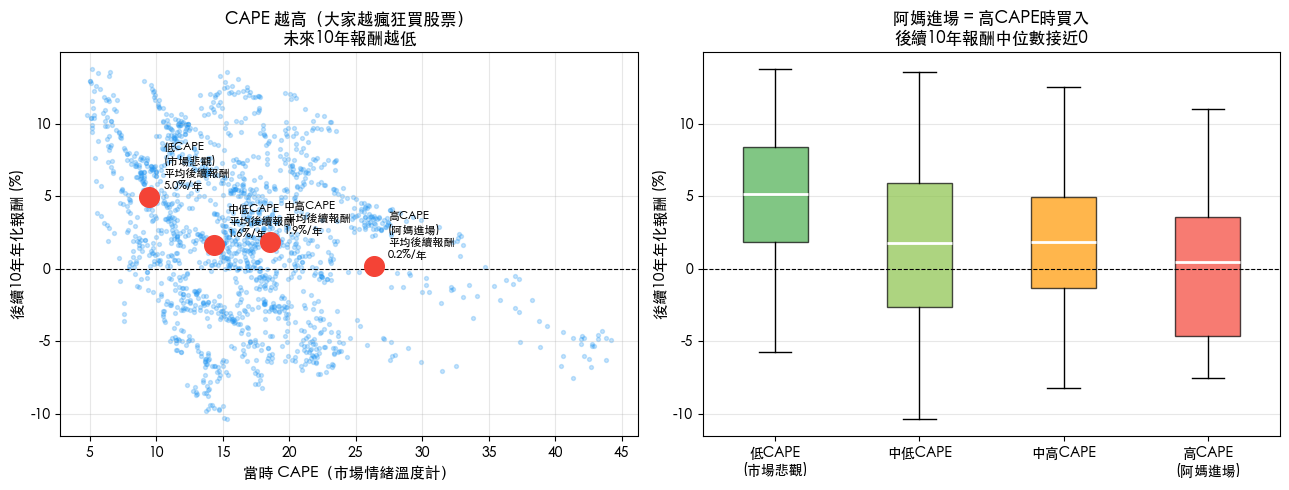


各情緒區間的後續10年年化報酬：
  低CAPE (市場悲觀)        : +4.95%/年
  中低CAPE              : +1.62%/年
  中高CAPE              : +1.87%/年
  高CAPE (阿媽進場)        : +0.22%/年


In [2]:
# 從 Shiller 數據：用 CAPE 高低代理散戶情緒
# CAPE 高 = 市場樂觀、人人追捧 = 阿媽理論啟動期

SHILLER_CSV = DATA_DIR / 'shiller_data.csv'
if SHILLER_CSV.exists():
    df = pd.read_csv(SHILLER_CSV, index_col=0, parse_dates=True)
else:
    import pandas_datareader.data as web
    raw = web.DataReader('shiller', 'quandl', start='1871-01-01')
    # fallback: download from Shiller's website
    url = 'http://www.econ.yale.edu/~shiller/data/ie_data.xls'
    raw = pd.read_excel(url, sheet_name='Data', skiprows=7, header=0)
    raw = raw.dropna(subset=[raw.columns[0]])
    df = pd.DataFrame({
        'price': pd.to_numeric(raw.iloc[:, 2], errors='coerce'),
        'cape':  pd.to_numeric(raw.iloc[:, 10], errors='coerce'),
    }).dropna()
    df.index = pd.to_datetime(raw.iloc[:len(df), 0].astype(str)
                              .str.replace(r'\.(\d)$', r'.0\1', regex=True), format='%Y.%m')
    df.to_csv(SHILLER_CSV)

# 計算後續10年實質報酬
df = df[df['cape'].notna() & (df['cape'] > 0)].copy()
df['real_price'] = df.get('real_price', df['price'])

# 按 CAPE 分成四個情緒區間
cape = df['cape'].dropna()
q = [0, 0.25, 0.5, 0.75, 1.0]
labels_q = ['低CAPE\n(市場悲觀)', '中低CAPE', '中高CAPE', '高CAPE\n(阿媽進場)']
df['cape_q'] = pd.qcut(df['cape'], q=4, labels=labels_q)

# 計算後續10年報酬（用 real_price 的 log return 近似）
price_col = 'real_price' if 'real_price' in df.columns else 'price'
df['fwd_10y'] = (df[price_col].shift(-120) / df[price_col]) ** (1/10) - 1
df_valid = df.dropna(subset=['fwd_10y', 'cape_q'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左圖：CAPE 與後續10年報酬的關係（散點圖）
axes[0].scatter(df_valid['cape'], df_valid['fwd_10y']*100,
                alpha=0.25, s=8, color='#2196F3')

# 四個區間的平均
group_means = df_valid.groupby('cape_q', observed=True)['fwd_10y'].mean() * 100
group_capes = df_valid.groupby('cape_q', observed=True)['cape'].mean()
for lbl in labels_q:
    if lbl in group_means.index:
        axes[0].scatter(group_capes[lbl], group_means[lbl], s=200,
                        color='#F44336', zorder=5)
        axes[0].annotate(f'{lbl}\n平均後續報酬\n{group_means[lbl]:.1f}%/年',
                         (group_capes[lbl], group_means[lbl]),
                         textcoords='offset points', xytext=(10,5), fontsize=8)

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('當時 CAPE（市場情緒溫度計）', fontsize=11)
axes[0].set_ylabel('後續10年年化報酬 (%)', fontsize=11)
axes[0].set_title('CAPE 越高（大家越瘋狂買股票）\n未來10年報酬越低', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# 右圖：各情緒區間的後續報酬分佈
colors_box = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336']
data_box = [df_valid[df_valid['cape_q']==l]['fwd_10y'].dropna()*100 for l in labels_q]
bp = axes[1].boxplot(data_box, labels=labels_q, patch_artist=True,
                      medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('後續10年年化報酬 (%)', fontsize=11)
axes[1].set_title('阿媽進場 = 高CAPE時買入\n後續10年報酬中位數接近0', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data/recency_bias_cape.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n各情緒區間的後續10年年化報酬：')
for lbl in labels_q:
    if lbl in group_means.index:
        print(f'  {lbl.replace(chr(10)," "):20s}: {group_means[lbl]:+.2f}%/年')

## 5｜其他常見散戶偏誤速覽

findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font fami

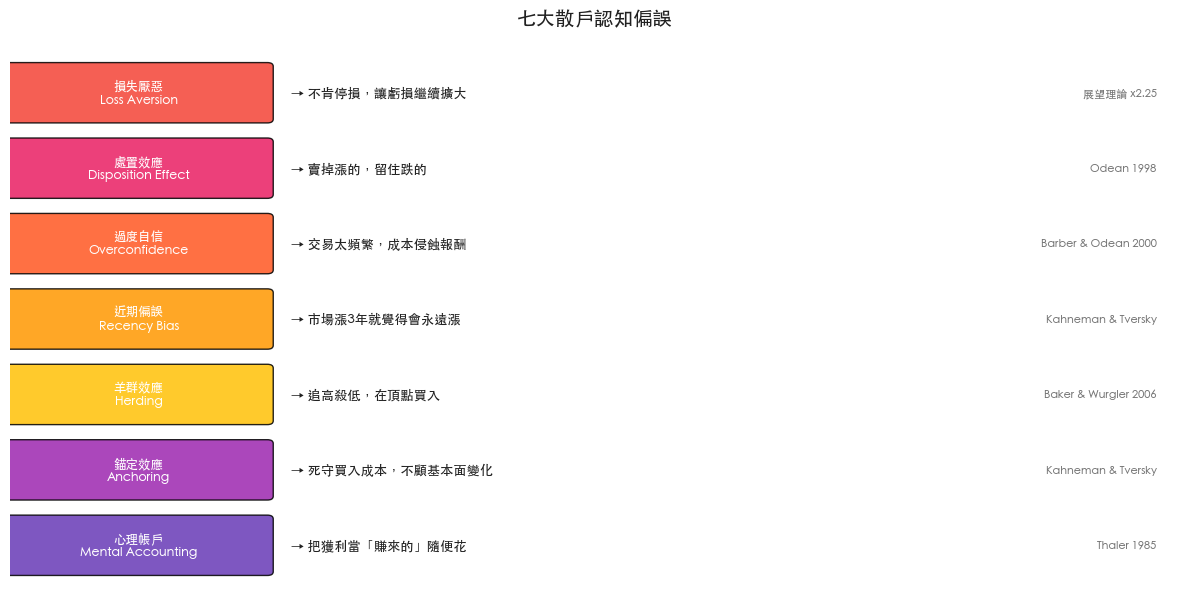

In [3]:
# 視覺化：七大偏誤 & 其影響方向
biases = [
    ('損失厭惡\nLoss Aversion',      '不肯停損，讓虧損繼續擴大',         '展望理論 x2.25'),
    ('處置效應\nDisposition Effect', '賣掉漲的，留住跌的',                'Odean 1998'),
    ('過度自信\nOverconfidence',      '交易太頻繁，成本侵蝕報酬',          'Barber & Odean 2000'),
    ('近期偏誤\nRecency Bias',        '市場漲3年就覺得會永遠漲',           'Kahneman & Tversky'),
    ('羊群效應\nHerding',             '追高殺低，在頂點買入',               'Baker & Wurgler 2006'),
    ('錨定效應\nAnchoring',           '死守買入成本，不顧基本面變化',       'Kahneman & Tversky'),
    ('心理帳戶\nMental Accounting',   '把獲利當「賺來的」隨便花',           'Thaler 1985'),
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, len(biases) - 0.5)
ax.axis('off')

colors_bias = ['#F44336','#E91E63','#FF5722','#FF9800','#FFC107','#9C27B0','#673AB7']

for i, (name, effect, source) in enumerate(biases):
    y = len(biases) - 1 - i
    # 偏誤名稱
    ax.add_patch(mpatches.FancyBboxPatch((0, y-0.35), 2.2, 0.7,
                 boxstyle='round,pad=0.05', facecolor=colors_bias[i], alpha=0.85))
    ax.text(1.1, y, name, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white')
    # 影響
    ax.text(2.4, y, f'→ {effect}', va='center', fontsize=9.5, color='#212121')
    # 學術來源
    ax.text(9.8, y, source, va='center', ha='right', fontsize=8, color='#757575',
            style='italic')

ax.text(5, len(biases)-0.1, '七大散戶認知偏誤', ha='center', fontsize=14,
        fontweight='bold', color='#212121')
ax.axhline(len(biases)-0.3, color='#BDBDBD', linewidth=1)

plt.tight_layout()
plt.savefig('data/seven_biases.png', dpi=150, bbox_inches='tight')
plt.show()

## 6｜這跟你有什麼關係？

### 散戶自我檢核清單

在每一筆投資決策前，問自己：

#### 🔴 停損相關（損失厭惡 + 處置效應）
- [ ] 我是因為「不想承認錯誤」才沒有停損嗎？
- [ ] 如果這支股票不是我持有的，我現在會買它嗎？
      （如果答案是「不會」，那你只是在錨定成本，不是在投資）

#### 🟡 交易頻率（過度自信）
- [ ] 我上個月交易了幾次？成本是多少？
- [ ] 我有記錄每次交易的「預期理由」和「實際結果」嗎？

#### 🟠 市場判斷（近期偏誤 + 羊群效應）
- [ ] 我現在覺得股市「很好」，是因為它最近確實漲了嗎？
- [ ] 最近有沒有人（鄰居、親戚、同事）開始問我怎麼買股票？
      （阿媽理論啟動訊號）

### 阿媽理論的反向操作

| 信號 | 市場可能狀態 | 建議動作 |
|------|-------------|----------|
| 所有人都在談股票、ETF | 可能高點 | 定期定額繼續，不要加碼 |
| 群組開始傳「股市要崩了」 | 可能低點 | 確認基本面是否改變 |
| 財經節目收視率創新高 | 市場頂部附近 | 小心槓桿和追高 |
| 沒人在談股票 | 市場底部附近 | 逢低分批加碼的好時機 |

### 行為金融給你的最大啟示

> 你最大的敵人不是市場，而是你自己的大腦。

建立**規則**，代替**感覺**：
- 設定停損點（例如：-15% 自動檢討）
- 定期定額（消除「現在是不是好時機」的焦慮）
- 記錄投資日誌（讓自己的偏誤無所遁形）

## 📌 本章重點摘要
| 偏誤 | 核心發現 | 對投資的影響 |
|------|----------|-------------|
| 損失厭惡 | 損失的痛苦是獲利喜悅的 2.25 倍 | 不肯停損，讓虧損繼續 |
| 處置效應 | 散戶賣贏機率是賣輸的 1.5 倍 | 剛好做反了動能效應 |
| 過度自信 | 換手率最高的散戶年報酬落後市場 5.7% | 少交易 = 多賺錢 |
| 近期偏誤 | 市場漲三年 → 散戶最樂觀 → 往往是頂點 | 阿媽進場要小心 |
| 解方 | 建立規則代替感覺 | 定期定額、設停損、記日誌 |

> **下一章：** Shiller CAPE——用 145 年數據，看現在的股市到底貴不貴